# Yakutia Asset Ownership & Economic Power Mapping
## Data Analysis Pipeline

**Project:** Who Owns Yakutia's Resource Empire?  
**Scope:** Asset-level ownership mapping across diamonds, coal, oil & gas, electricity, transport  
**Methodology:** Revenue-weighted ownership analysis by entity type  

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = Path('..')
DATA_DIR   = BASE_DIR / 'data' / 'cleaned'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'
TABLES_DIR = BASE_DIR / 'outputs' / 'tables'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ── Consistent color palette ───────────────────────────────────────────────
OWNER_COLORS = {
    'federal':   '#C0392B',
    'regional':  '#2E86C1',
    'municipal': '#1ABC9C',
    'private':   '#7F8C8D',
    'foreign':   '#27AE60'
}

OWNER_LABELS = {
    'federal':   'Federal (Russian Federation)',
    'regional':  'Regional (Republic of Sakha)',
    'municipal': 'Municipal (Yakutia Districts)',
    'private':   'Private / Corporate',
    'foreign':   'Foreign Investors'
}

# ── Global chart style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     14,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'figure.facecolor':   'white',
    'axes.facecolor':     '#F8F9FA',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#DDDDDD',
    'grid.linewidth':     0.6,
})

print('Setup complete. Chart output:', CHARTS_DIR.resolve())

Setup complete. Chart output: C:\Users\aisen\OneDrive\Рабочий стол\Yakutia's Resource Empire Who Owns It, Who Profits, and What the Republic Actually Gets\yakutia-asset-analysis\outputs\charts


## 1. Load & Validate Data

In [2]:
df = pd.read_csv(DATA_DIR / 'yakutia_assets.csv')

# Basic validation
assert df['owner_type'].isin(OWNER_COLORS.keys()).all(), 'Unknown owner_type values'
assert (df['ownership_percentage'] > 0).all(), 'Zero ownership rows found'
assert (df['estimated_revenue_usd_m'] >= 0).all(), 'Negative revenue'

print(f'Rows: {len(df)}  |  Asset types: {df["asset_type"].nunique()}  |  Owner types: {df["owner_type"].nunique()}')
df.head(10)

Rows: 25  |  Asset types: 9  |  Owner types: 5


,asset_id,asset_name,asset_type,company,owner_entity,owner_type,ownership_percentage,estimated_revenue_usd_m,strategic_importance,notes
0,1,ALROSA Diamond Mining,diamond,ALROSA PJSC,Russian Federation,federal,33.02,1387,high,Via Rosimushchestvo (Federal Property Agency);...
1,2,ALROSA Diamond Mining,diamond,ALROSA PJSC,Republic of Sakha (Yakutia),regional,25.00,1050,high,Direct government stake per ALROSA charter and...
2,3,ALROSA Diamond Mining,diamond,ALROSA PJSC,Municipal Districts (Yakutia),municipal,8.00,336,high,Distributed across 8 municipal raions of Yakutia
3,4,ALROSA Diamond Mining,diamond,ALROSA PJSC,Public Investors (Free Float),private,33.98,1427,high,Free float traded on Moscow Exchange (MOEX tic...
4,5,Yakutugol Coal Operations,coal,Mechel (Yakutugol subsidiary),Mechel Group (I. Zyuzin majority),private,100.00,580,high,Coking coal operations centered in Neryungri; ...
5,6,Yakutia Airlines,aviation,FSUE Yakutia Airlines,Republic of Sakha (Yakutia),regional,99.00,95,medium,Critical connectivity for remote settlements; ...
6,7,Yakutia Airlines,aviation,FSUE Yakutia Airlines,Minority Private Shareholders,private,1.00,1,medium,Residual private stake; operationally irrelevant
7,8,TAAS-Yuryakh Neftegazodobycha,oil_gas,TAAS-Yuryakh NGC PJSC,Rosneft (federal),federal,56.10,452,high,Eastern Siberia Chayandinsk oilfield; Rosneft ...
8,9,TAAS-Yuryakh Neftegazodobycha,oil_gas,TAAS-Yuryakh NGC PJSC,Indian Consortium (ONGC Videsh / OIL / IOC),foreign,23.90,193,high,Acquired 2016 via strategic energy partnership...
9,10,TAAS-Yuryakh Neftegazodobycha,oil_gas,TAAS-Yuryakh NGC PJSC,BP Russia via LetterOne,foreign,20.00,161,high,Pre-2022 stake; BP exited Russia in 2022 (stat...


## 2. Feature Engineering — Revenue-Weighted Ownership

In [3]:
# Revenue attributable to each ownership stake
df['attributed_revenue_m'] = (
    df['estimated_revenue_usd_m'] * df['ownership_percentage'] / 100
).round(1)

# Ordered categories for charts
STRAT_ORDER = ['high', 'medium', 'low']
TYPE_ORDER  = ['diamond', 'oil_gas', 'coal', 'electricity', 'transport', 'gas', 'gold', 'timber']

df['strategic_importance'] = pd.Categorical(df['strategic_importance'], categories=STRAT_ORDER, ordered=True)
df['asset_type']           = pd.Categorical(df['asset_type'],           categories=TYPE_ORDER,  ordered=True)

# Summary
total_rev = df['attributed_revenue_m'].sum()
print(f'Total attributed revenue in dataset: ${total_rev:,.0f}M  (≈ ${total_rev/1000:.1f}B)')

by_type = (
    df.groupby('owner_type', observed=True)['attributed_revenue_m']
    .sum()
    .sort_values(ascending=False)
)
print('\nRevenue by ownership type (USD M):')
print(by_type.to_string())

Total attributed revenue in dataset: $5,682M  (≈ $5.7B)

Revenue by ownership type (USD M):
owner_type
private      3486.1
federal      1458.4
regional      632.5
foreign        78.3
municipal      26.9


## 3. Chart 1 — Ownership Distribution Donut
> **Insight:** The majority of revenue-generating assets are controlled by federal entities and private corporations, with the Republic of Sakha retaining a comparatively limited direct stake despite hosting all resources.

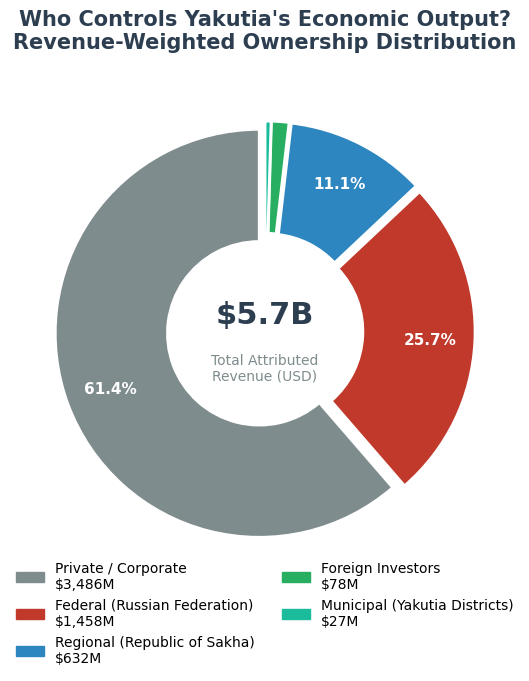

Saved: ..\outputs\charts\01_ownership_donut.png


In [4]:
def plot_ownership_donut(df: pd.DataFrame, save_path: Path) -> None:
    by_owner = (
        df.groupby('owner_type', observed=True)['attributed_revenue_m']
        .sum()
        .sort_values(ascending=False)
    )
    total = by_owner.sum()
    labels   = [OWNER_LABELS[k] for k in by_owner.index]
    colors   = [OWNER_COLORS[k]  for k in by_owner.index]
    sizes    = by_owner.values
    explode  = [0.03] * len(sizes)

    fig, ax = plt.subplots(figsize=(9, 7), facecolor='white')
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=None,
        colors=colors,
        explode=explode,
        autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
        pctdistance=0.78,
        startangle=90,
        wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
        textprops=dict(fontsize=11, fontweight='bold', color='white')
    )

    # Centre annotation
    ax.text(0, 0.08, f'${total/1000:.1f}B', ha='center', va='center',
            fontsize=22, fontweight='bold', color='#2C3E50')
    ax.text(0, -0.18, 'Total Attributed\nRevenue (USD)', ha='center', va='center',
            fontsize=10, color='#7F8C8D')

    # Legend
    legend_labels = [f'{l}\n${v:,.0f}M' for l, v in zip(labels, sizes)]
    patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, legend_labels)]
    ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.18),
              ncol=2, frameon=False, fontsize=10)

    ax.set_title(
        'Who Controls Yakutia\'s Economic Output?\nRevenue-Weighted Ownership Distribution',
        fontsize=15, fontweight='bold', color='#2C3E50', pad=20
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')

plot_ownership_donut(df, CHARTS_DIR / '01_ownership_donut.png')

## 4. Chart 2 — Top Controlling Entities (Bar Chart)
> **Insight:** Economic control is highly concentrated. The top 5 entities account for the overwhelming majority of total attributed revenue, with no single regional entity appearing among the top earners.

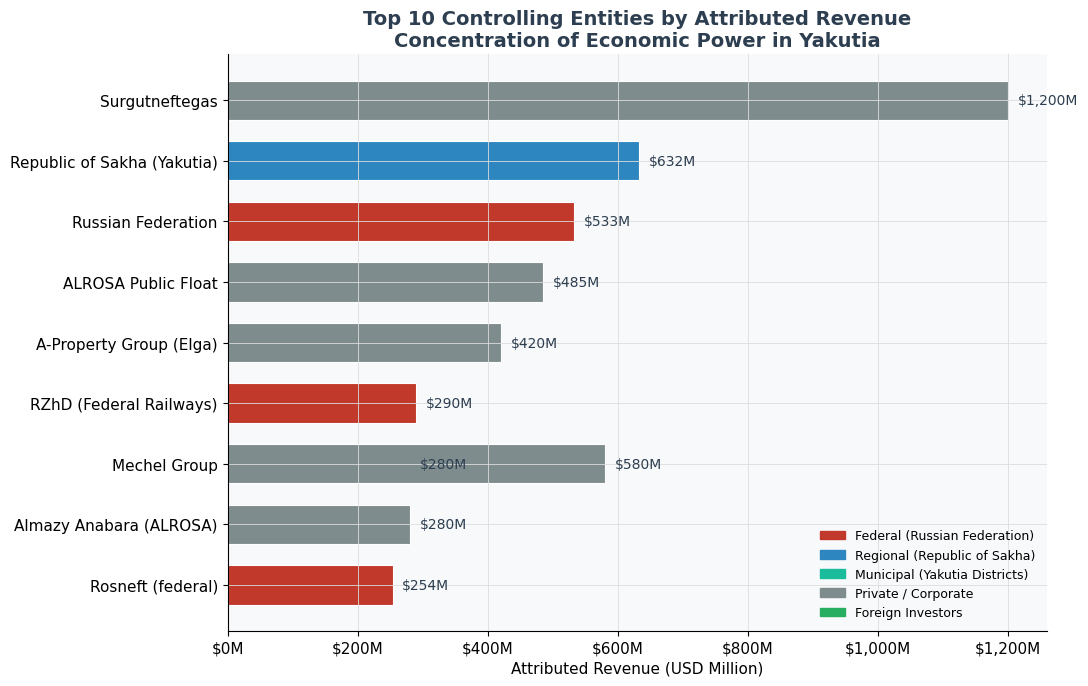

Saved: ..\outputs\charts\02_top_entities_bar.png


In [5]:
def plot_top_entities(df: pd.DataFrame, save_path: Path, top_n: int = 10) -> None:
    by_entity = (
        df.groupby(['owner_entity', 'owner_type'], observed=True)['attributed_revenue_m']
        .sum()
        .reset_index()
        .sort_values('attributed_revenue_m', ascending=True)
        .tail(top_n)
    )

    # Shorten long entity names
    name_map = {
        'Russian Federation (RZhD)':           'RZhD (Federal Railways)',
        'Surgutneftegas (private / opaque structure)': 'Surgutneftegas',
        'Mechel Group (I. Zyuzin majority)':   'Mechel Group',
        'Public Investors (Free Float)':        'ALROSA Public Float',
        'A-Property Group (private)':           'A-Property Group (Elga)',
        'ALROSA PJSC (subsidiary)':             'Almazy Anabara (ALROSA)',
        'Mechel Subsidiaries':                  'Mechel (Neryungri Zone)',
        'Indian Consortium (ONGC Videsh / OIL / IOC)': 'Indian Consortium (TAAS)',
        'BP Russia via LetterOne':              'BP Russia (TAAS)',
        'Private Investors (mixed)':            'Gold Sector (Private)',
    }
    by_entity['label'] = by_entity['owner_entity'].replace(name_map)
    colors = [OWNER_COLORS[t] for t in by_entity['owner_type']]

    fig, ax = plt.subplots(figsize=(11, 7), facecolor='white')
    bars = ax.barh(
        by_entity['label'],
        by_entity['attributed_revenue_m'],
        color=colors,
        edgecolor='white',
        linewidth=0.8,
        height=0.65
    )

    # Value labels
    for bar, val in zip(bars, by_entity['attributed_revenue_m']):
        ax.text(val + 15, bar.get_y() + bar.get_height() / 2,
                f'${val:,.0f}M', va='center', fontsize=10, color='#2C3E50')

    # Legend
    patches = [mpatches.Patch(color=v, label=OWNER_LABELS[k]) for k, v in OWNER_COLORS.items()]
    ax.legend(handles=patches, loc='lower right', frameon=False, fontsize=9)

    ax.set_xlabel('Attributed Revenue (USD Million)', fontsize=11)
    ax.set_title(
        f'Top {top_n} Controlling Entities by Attributed Revenue\nConcentration of Economic Power in Yakutia',
        fontsize=14, fontweight='bold', color='#2C3E50'
    )
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.set_facecolor('#F8F9FA')
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')

plot_top_entities(df, CHARTS_DIR / '02_top_entities_bar.png')

## 5. Chart 3 — Asset Type vs Ownership Type Heatmap
> **Insight:** Natural resource sectors (diamonds, coal, oil & gas) are controlled predominantly by federal or private corporate entities. The Republic of Sakha's direct ownership is meaningful only in aviation and regional gas — economically marginal sectors relative to the resource base.

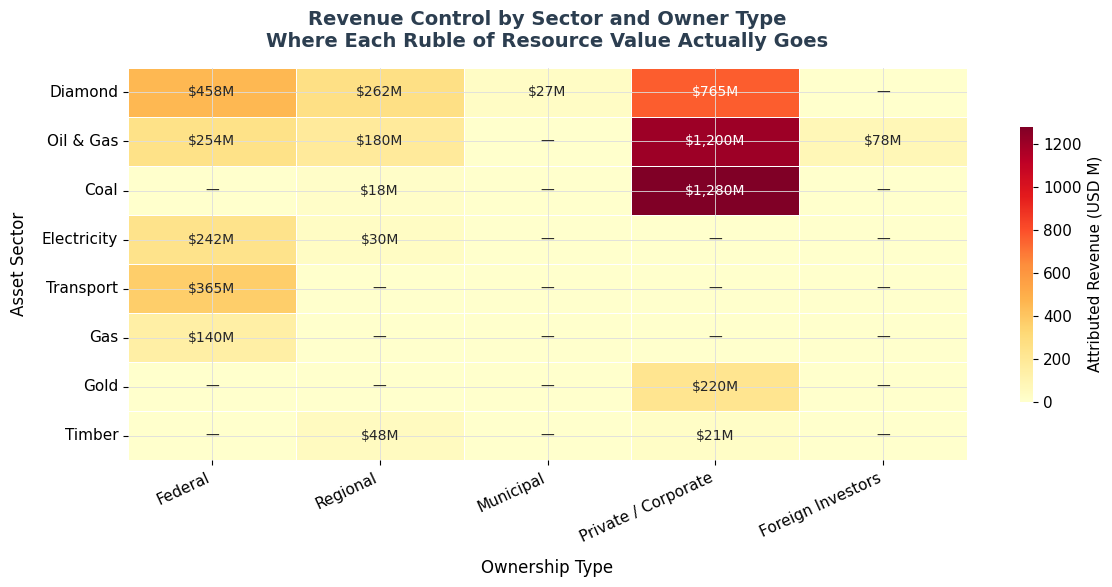

Saved: ..\outputs\charts\03_sector_ownership_heatmap.png


In [6]:
def plot_heatmap(df: pd.DataFrame, save_path: Path) -> None:
    pivot = (
        df.groupby(['asset_type', 'owner_type'], observed=True)['attributed_revenue_m']
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=list(OWNER_COLORS.keys()), fill_value=0)
    )
    pivot.index = [t.replace('_', ' & ').title() for t in pivot.index]
    pivot.columns = [OWNER_LABELS[c].split(' (')[0] for c in pivot.columns]

    # Mask zeros for annotation clarity
    annot = pivot.applymap(lambda v: f'${v:,.0f}M' if v > 0 else '—')

    fig, ax = plt.subplots(figsize=(12, 6), facecolor='white')
    sns.heatmap(
        pivot,
        annot=annot,
        fmt='',
        cmap='YlOrRd',
        linewidths=0.5,
        linecolor='white',
        ax=ax,
        cbar_kws={'label': 'Attributed Revenue (USD M)', 'shrink': 0.7},
        annot_kws={'size': 10}
    )

    ax.set_xlabel('Ownership Type', fontsize=12, labelpad=10)
    ax.set_ylabel('Asset Sector', fontsize=12, labelpad=10)
    ax.set_title(
        'Revenue Control by Sector and Owner Type\nWhere Each Ruble of Resource Value Actually Goes',
        fontsize=14, fontweight='bold', color='#2C3E50', pad=15
    )
    plt.xticks(rotation=25, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')

plot_heatmap(df, CHARTS_DIR / '03_sector_ownership_heatmap.png')

## 6. Chart 4 — Strategic Importance vs Ownership Type
> **Insight:** High-strategic-importance assets are overwhelmingly controlled by federal and private entities. The Republic of Sakha controls a disproportionately small share of its most strategically critical resources.

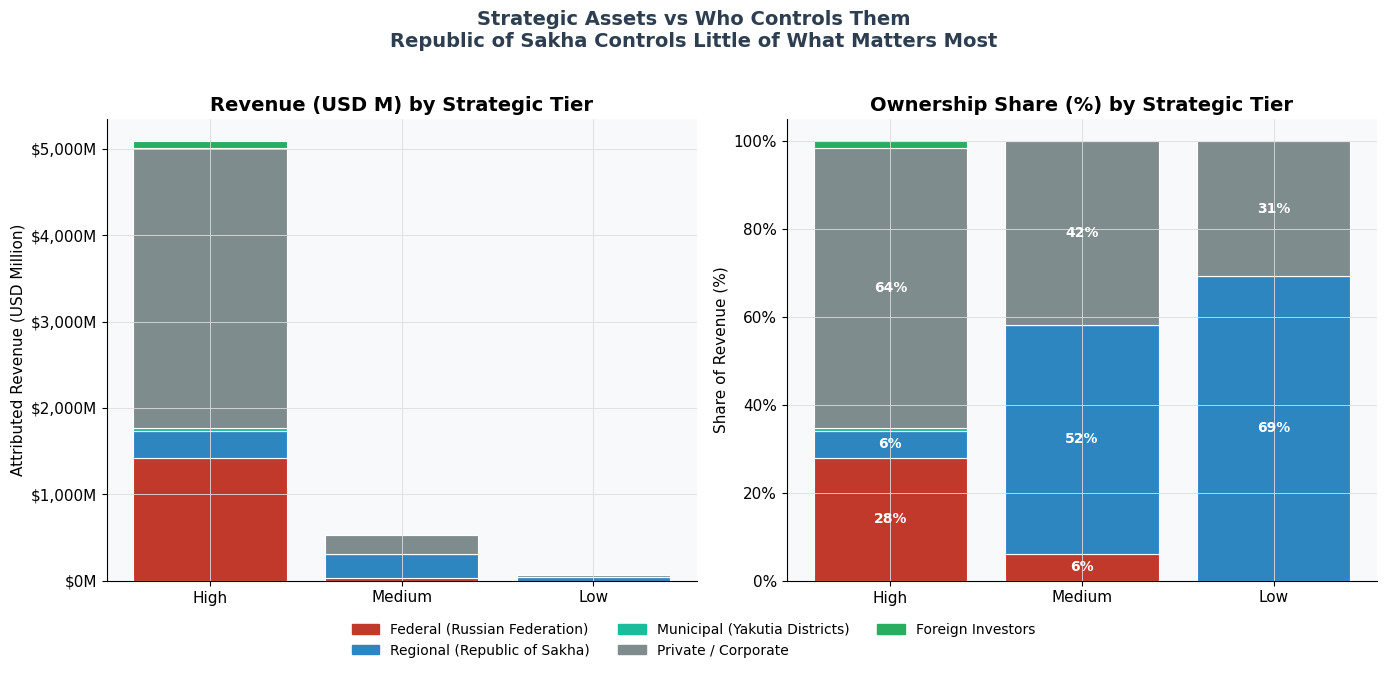

Saved: ..\outputs\charts\04_strategic_vs_ownership.png


In [7]:
def plot_strategic_vs_ownership(df: pd.DataFrame, save_path: Path) -> None:
    strat_pivot = (
        df.groupby(['strategic_importance', 'owner_type'], observed=True)['attributed_revenue_m']
        .sum()
        .unstack(fill_value=0)
        .reindex(columns=list(OWNER_COLORS.keys()), fill_value=0)
    )

    strat_pivot_pct = strat_pivot.div(strat_pivot.sum(axis=1), axis=0) * 100
    strat_pivot_pct.index = [s.capitalize() + ' Strategic' for s in strat_pivot_pct.index]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

    # ── Left: Stacked bar (absolute USD) ──────────────────────────────────
    ax1 = axes[0]
    bottom = np.zeros(len(strat_pivot))
    for col in strat_pivot.columns:
        ax1.bar(
            strat_pivot.index,
            strat_pivot[col],
            bottom=bottom,
            color=OWNER_COLORS[col],
            label=OWNER_LABELS[col],
            edgecolor='white',
            linewidth=0.8
        )
        bottom += strat_pivot[col].values

    ax1.set_title('Revenue (USD M) by Strategic Tier', fontweight='bold')
    ax1.set_ylabel('Attributed Revenue (USD Million)')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax1.set_xticklabels(['High', 'Medium', 'Low'])
    ax1.set_facecolor('#F8F9FA')

    # ── Right: 100% stacked bar (share) ───────────────────────────────────
    ax2 = axes[1]
    bottom = np.zeros(len(strat_pivot_pct))
    for col in strat_pivot_pct.columns:
        ax2.bar(
            strat_pivot_pct.index,
            strat_pivot_pct[col],
            bottom=bottom,
            color=OWNER_COLORS[col],
            edgecolor='white',
            linewidth=0.8
        )
        # Annotate significant segments
        for i, (h, b) in enumerate(zip(strat_pivot_pct[col], bottom)):
            if h > 6:
                ax2.text(i, b + h / 2, f'{h:.0f}%', ha='center', va='center',
                         fontsize=10, fontweight='bold', color='white')
        bottom += strat_pivot_pct[col].values

    ax2.set_title('Ownership Share (%) by Strategic Tier', fontweight='bold')
    ax2.set_ylabel('Share of Revenue (%)')
    ax2.set_ylim(0, 105)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax2.set_xticklabels(['High', 'Medium', 'Low'])
    ax2.set_facecolor('#F8F9FA')

    # Shared legend
    patches = [mpatches.Patch(color=OWNER_COLORS[k], label=OWNER_LABELS[k]) for k in OWNER_COLORS]
    fig.legend(handles=patches, loc='lower center', ncol=3, frameon=False,
               fontsize=10, bbox_to_anchor=(0.5, -0.08))

    fig.suptitle(
        'Strategic Assets vs Who Controls Them\nRepublic of Sakha Controls Little of What Matters Most',
        fontsize=14, fontweight='bold', color='#2C3E50', y=1.02
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')

plot_strategic_vs_ownership(df, CHARTS_DIR / '04_strategic_vs_ownership.png')

## 7. Summary Statistics & Table Export

In [8]:
# ── Table 1: Revenue share by owner type ──────────────────────────────────
total = df['attributed_revenue_m'].sum()
ownership_summary = (
    df.groupby('owner_type', observed=True)['attributed_revenue_m']
    .sum()
    .reset_index()
    .rename(columns={'owner_type': 'Ownership Type', 'attributed_revenue_m': 'Revenue (USD M)'})
    .sort_values('Revenue (USD M)', ascending=False)
)
ownership_summary['Share (%)'] = (ownership_summary['Revenue (USD M)'] / total * 100).round(1)
ownership_summary['Ownership Type'] = ownership_summary['Ownership Type'].map(OWNER_LABELS)
ownership_summary.to_csv(TABLES_DIR / 'table1_ownership_summary.csv', index=False)

print('=== TABLE 1: Revenue Share by Ownership Type ===')
print(ownership_summary.to_string(index=False))

# ── Table 2: Top entities ──────────────────────────────────────────────────
entity_summary = (
    df.groupby(['owner_entity', 'owner_type'], observed=True)['attributed_revenue_m']
    .sum()
    .reset_index()
    .sort_values('attributed_revenue_m', ascending=False)
    .head(12)
)
entity_summary['share_pct'] = (entity_summary['attributed_revenue_m'] / total * 100).round(1)
entity_summary.to_csv(TABLES_DIR / 'table2_top_entities.csv', index=False)

print('\n=== TABLE 2: Top 12 Entities ===')
print(entity_summary.to_string(index=False))

# ── Table 3: Sector concentration ─────────────────────────────────────────
sector_summary = (
    df.groupby(['asset_type', 'owner_type'], observed=True)['attributed_revenue_m']
    .sum()
    .unstack(fill_value=0)
)
sector_summary['TOTAL'] = sector_summary.sum(axis=1)
sector_summary.to_csv(TABLES_DIR / 'table3_sector_x_owner.csv')

print('\n=== TABLE 3: Sector × Ownership Matrix (USD M) ===')
print(sector_summary.to_string())

=== TABLE 1: Revenue Share by Ownership Type ===
               Ownership Type  Revenue (USD M)  Share (%)
          Private / Corporate           3486.1       61.4
 Federal (Russian Federation)           1458.4       25.7
 Regional (Republic of Sakha)            632.5       11.1
            Foreign Investors             78.3        1.4
Municipal (Yakutia Districts)             26.9        0.5

=== TABLE 2: Top 12 Entities ===
                               owner_entity owner_type  attributed_revenue_m  share_pct
Surgutneftegas (private / opaque structure)    private                1200.0       21.1
                Republic of Sakha (Yakutia)   regional                 632.5       11.1
          Mechel Group (I. Zyuzin majority)    private                 580.0       10.2
                         Russian Federation    federal                 533.0        9.4
              Public Investors (Free Float)    private                 484.9        8.5
                 A-Property Group (privat

## 8. Key Findings Summary

In [9]:
fed_share   = df[df['owner_type'] == 'federal']['attributed_revenue_m'].sum() / total * 100
reg_share   = df[df['owner_type'] == 'regional']['attributed_revenue_m'].sum() / total * 100
priv_share  = df[df['owner_type'] == 'private']['attributed_revenue_m'].sum() / total * 100
mun_share   = df[df['owner_type'] == 'municipal']['attributed_revenue_m'].sum() / total * 100
for_share   = df[df['owner_type'] == 'foreign']['attributed_revenue_m'].sum() / total * 100

high_strat  = df[df['strategic_importance'] == 'high']
reg_high    = high_strat[high_strat['owner_type'] == 'regional']['attributed_revenue_m'].sum()
total_high  = high_strat['attributed_revenue_m'].sum()
reg_high_pct = reg_high / total_high * 100

top_entity  = (
    df.groupby('owner_entity', observed=True)['attributed_revenue_m']
    .sum().sort_values(ascending=False)
)
top5_share  = top_entity.head(5).sum() / total * 100

print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(' YAKUTIA ASSET OWNERSHIP — KEY FINDINGS')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'\n[1] FEDERAL DOMINANCE')
print(f'    Federal entities control {fed_share:.1f}% of total attributed revenue.')
print(f'    Regional (Yakutia) controls only {reg_share:.1f}%.')
print(f'\n[2] PRIVATE / CORPORATE POWER')
print(f'    Private corporations control {priv_share:.1f}% — comparable to federal share.')
print(f'\n[3] FOREIGN EXPOSURE')
print(f'    Foreign investors hold {for_share:.1f}% (Indian consortium + BP, pre-2022 baseline).')
print(f'\n[4] MUNICIPAL SHARE')
print(f'    Municipal districts (via ALROSA) hold {mun_share:.1f}% — small but noteworthy.')
print(f'\n[5] STRATEGIC ASSET MISMATCH')
print(f'    Of HIGH-strategic assets: Republic of Sakha controls only {reg_high_pct:.1f}%.')
print(f'\n[6] CONCENTRATION')
print(f'    Top 5 entities control {top5_share:.1f}% of total revenue.')
print(f'\n[7] LARGEST SINGLE CONTROLLER')
print(f'    {top_entity.index[0]}: ${top_entity.iloc[0]:,.0f}M ({top_entity.iloc[0]/total*100:.1f}%)')
print('━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 YAKUTIA ASSET OWNERSHIP — KEY FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

[1] FEDERAL DOMINANCE
    Federal entities control 25.7% of total attributed revenue.
    Regional (Yakutia) controls only 11.1%.

[2] PRIVATE / CORPORATE POWER
    Private corporations control 61.4% — comparable to federal share.

[3] FOREIGN EXPOSURE
    Foreign investors hold 1.4% (Indian consortium + BP, pre-2022 baseline).

[4] MUNICIPAL SHARE
    Municipal districts (via ALROSA) hold 0.5% — small but noteworthy.

[5] STRATEGIC ASSET MISMATCH
    Of HIGH-strategic assets: Republic of Sakha controls only 6.1%.

[6] CONCENTRATION
    Top 5 entities control 60.4% of total revenue.

[7] LARGEST SINGLE CONTROLLER
    Surgutneftegas (private / opaque structure): $1,200M (21.1%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [ ]:
def plot_alrosa_dividends(save_path: Path) -> None:
    # ALROSA dividend data from annual reports.
    # Republic of Sakha holds a fixed 25% stake — its share is always 25% of whatever ALROSA declares.
    # 2022: ALROSA suspended dividends following Western sanctions on diamond exports.
    data = pd.DataFrame([
        {'year': 2016, 'alrosa_rub_b': 62.6,  'rate': 67.0},
        {'year': 2017, 'alrosa_rub_b': 34.4,  'rate': 58.3},
        {'year': 2018, 'alrosa_rub_b': 28.3,  'rate': 62.7},
        {'year': 2019, 'alrosa_rub_b': 51.5,  'rate': 64.7},
        {'year': 2020, 'alrosa_rub_b': 7.0,   'rate': 72.1},   # COVID — board cut to minimal payout
        {'year': 2021, 'alrosa_rub_b': 107.0, 'rate': 73.7},   # Record year; diamond demand surge
        {'year': 2022, 'alrosa_rub_b': 0.0,   'rate': 68.5},   # Suspended: Western sanctions
    ])
    data['republic_usd_m'] = (data['alrosa_rub_b'] * 1e9 * 0.25 / data['rate'] / 1e6).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), facecolor='white')

    bar_colors = lambda series: ['#E74C3C' if v == 0 else '#2E86C1' for v in series]

    # Left: ALROSA total declared dividend (₽B)
    ax1 = axes[0]
    bars1 = ax1.bar(data['year'], data['alrosa_rub_b'],
                    color=bar_colors(data['alrosa_rub_b']),
                    edgecolor='white', linewidth=0.9, width=0.65)
    for _, row in data.iterrows():
        if row['alrosa_rub_b'] > 0:
            ax1.text(row['year'], row['alrosa_rub_b'] + 1.8,
                     f"₽{row['alrosa_rub_b']:.0f}B",
                     ha='center', fontsize=9.5, fontweight='bold', color='#2C3E50')
        else:
            ax1.text(row['year'], 5, 'SUSPENDED\n(sanctions)', ha='center',
                     fontsize=8.5, color='#C0392B', fontweight='bold')
    ax1.set_title('ALROSA Total Declared Dividend\n(₽ Billion, all shareholders)', fontweight='bold', fontsize=12)
    ax1.set_ylabel('₽ Billion', fontsize=11)
    ax1.set_ylim(0, 135)
    ax1.set_facecolor('#F8F9FA')

    # Right: Republic of Sakha's 25% slice in USD
    ax2 = axes[1]
    ax2.bar(data['year'], data['republic_usd_m'],
            color=bar_colors(data['republic_usd_m']),
            edgecolor='white', linewidth=0.9, width=0.65)
    for _, row in data.iterrows():
        if row['republic_usd_m'] > 0:
            ax2.text(row['year'], row['republic_usd_m'] + 4,
                     f"${row['republic_usd_m']:.0f}M",
                     ha='center', fontsize=9.5, fontweight='bold', color='#2C3E50')
        else:
            ax2.text(row['year'], 8, '$0', ha='center',
                     fontsize=11, color='#C0392B', fontweight='bold')

    # 6-year average
    avg = data['republic_usd_m'].mean()
    ax2.axhline(avg, color='#F39C12', linewidth=1.6, linestyle='--', alpha=0.85)
    ax2.text(2016.4, avg + 7, f'6-yr avg: ${avg:.0f}M/yr', color='#F39C12', fontsize=9.5)

    # Peak → zero annotation
    peak = data['republic_usd_m'].max()
    ax2.annotate(
        f'2021 → 2022\n${peak:.0f}M → $0\n(−100% YoY)',
        xy=(2022, 0), xytext=(2019.8, 220),
        fontsize=8.5, color='#C0392B',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDEDEC', edgecolor='#E74C3C'),
        arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.3),
    )

    ax2.set_title("Republic of Sakha's ALROSA Dividend Income\n(USD Million — 25% stake @ annual avg RUB/USD)",
                  fontweight='bold', fontsize=12)
    ax2.set_ylabel('USD Million', fontsize=11)
    ax2.set_ylim(0, 410)
    ax2.set_facecolor('#F8F9FA')

    fig.suptitle(
        "Yakutia's Primary Cash Return from Resources Depends on a Board Vote in Moscow\n"
        "ALROSA Dividend Declarations 2016–2022 — the Republic Has No Vote on Whether It Receives Income",
        fontsize=12, fontweight='bold', color='#2C3E50', y=1.03,
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')

    peak_yr = data.loc[data['republic_usd_m'].idxmax(), 'year']
    print(f'\nPeak:  {peak_yr} — ${data["republic_usd_m"].max():.0f}M')
    print(f'Trough: 2022 — $0  (dividend suspended)')
    print(f'Range:  ${data["republic_usd_m"].min():.0f}M – ${data["republic_usd_m"].max():.0f}M  '
          f'(swing = ${data["republic_usd_m"].max() - data["republic_usd_m"].min():.0f}M)')
    print(f'This swing exceeds the entire Yakutia Airlines annual revenue (${95:.0f}M) by {(data["republic_usd_m"].max()-data["republic_usd_m"].min())/95:.0f}×')

plot_alrosa_dividends(CHARTS_DIR / '07_alrosa_dividend_volatility.png')

## 11. Chart 7 — ALROSA Dividend Volatility: Yakutia's Fiscal Vulnerability
> **Insight:** Because ALROSA dividends are the republic's primary cash return from resource wealth, Yakutia's budget is hostage to a corporate board decision in Moscow. In 2021 the republic received an estimated ~$362M; in 2022, following sanctions and dividend suspension, it received ~$0. This is not a revenue *decline* — it is a structural *off switch* that the republic cannot control.

In [ ]:
def plot_revenue_extraction_gap(df: pd.DataFrame, save_path: Path) -> None:
    # Build sector totals from the dataset
    sector_total = (
        df.groupby('asset_type', observed=True)['attributed_revenue_m']
        .sum()
        .rename('total_m')
    )
    sector_regional = (
        df[df['owner_type'] == 'regional']
        .groupby('asset_type', observed=True)['attributed_revenue_m']
        .sum()
        .rename('yakutia_m')
    )
    gap = pd.concat([sector_total, sector_regional], axis=1).fillna(0)
    gap['external_m'] = gap['total_m'] - gap['yakutia_m']
    gap['retention_pct'] = (gap['yakutia_m'] / gap['total_m'] * 100).round(1)

    # Human-readable labels
    sector_labels = {
        'diamond': 'Diamonds', 'oil_gas': 'Oil & Gas', 'coal': 'Coal',
        'electricity': 'Electricity', 'transport': 'Transport (Rail)', 'gas': 'Gas Distribution',
        'gold': 'Gold', 'timber': 'Timber', 'aviation': 'Aviation',
    }
    gap.index = [sector_labels.get(s, s) for s in gap.index]
    gap = gap.sort_values('total_m', ascending=True)

    fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
    y = range(len(gap))

    ax.barh(y, gap['external_m'], color='#E74C3C', alpha=0.82,
            label='Flows to external entities (federal / private / foreign)', height=0.62)
    ax.barh(y, gap['yakutia_m'], left=gap['external_m'], color='#2E86C1', alpha=0.92,
            label='Stays in Yakutia (regional attributed revenue)', height=0.62)

    ax.set_yticks(list(y))
    ax.set_yticklabels(gap.index, fontsize=11)

    for i, (_, row) in enumerate(gap.iterrows()):
        rate = row['retention_pct']
        color = '#2E86C1' if rate >= 15 else ('#F39C12' if rate > 0 else '#C0392B')
        label = f'{rate:.0f}% retained' if rate > 0 else '0% retained'
        ax.text(row['total_m'] + 18, i, label, va='center', fontsize=9.5, color=color, fontweight='bold')

    # Grand total callout
    total_in  = gap['yakutia_m'].sum()
    total_out = gap['external_m'].sum()
    grand     = total_in + total_out
    ax.text(0.98, 0.04,
            f"Total in dataset: ${grand:,.0f}M\n"
            f"Yakutia retains:  ${total_in:,.0f}M  ({total_in/grand*100:.1f}%)\n"
            f"Leaves Yakutia:   ${total_out:,.0f}M  ({total_out/grand*100:.1f}%)",
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.45', facecolor='white', edgecolor='#CCCCCC'))

    ax.set_xlabel('Attributed Revenue (USD Million)', fontsize=11)
    ax.set_title(
        'The Revenue Extraction Gap: What Leaves vs. What Stays in Yakutia\n'
        'For every dollar of resource value generated, how much does the republic keep?',
        fontsize=13, fontweight='bold', color='#2C3E50', pad=14,
    )
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
    ax.legend(loc='lower right', frameon=False, fontsize=10)
    ax.set_facecolor('#F8F9FA')

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')
    print(f'\nSector retention rates:')
    print(gap[['total_m','yakutia_m','retention_pct']].sort_values('retention_pct', ascending=False).to_string())

plot_revenue_extraction_gap(df, CHARTS_DIR / '06_revenue_extraction_gap.png')

## 10. Chart 6 — The Revenue Extraction Gap: What Leaves vs. What Stays
> **Insight:** Coal and transport generate over $1.6B in attributed revenue from Yakutia, yet the republic retains effectively nothing — 1.4% and 0% respectively. Even in diamonds, Yakutia's best sector, 83% of attributed value flows externally. The chart makes the "resource colony" dynamic visible at the sector level.

In [ ]:
def plot_ownership_erosion(save_path: Path) -> None:
    # Estimates reconstructed from documented ownership events.
    # Soviet baseline: regional party structures had de facto control over enterprise output.
    # 1993: ALROSA founded with ~40% republic stake; coal/energy still state-transitioning.
    # 2007: Mechel acquires Yakutugol at federal auction (republic excluded from mining).
    # 2011: ALROSA IPO on MOEX dilutes republic stake from ~37% to 25%.
    # 2019: RusHydro consolidates Yakutskenergo (republic: ~49% → 27.6%).
    trend = [
        (1990, 60.0, 'Soviet baseline\n(de facto regional\ncontrol)'),
        (1993, 42.0, 'ALROSA founded\n(40% republic stake;\ncoal still in transition)'),
        (1998, 33.0, 'Federal Subsoil Law (1995)\ncentralizes licensing;\nSurgutneftegas expands'),
        (2007, 20.0, 'Mechel acquires Yakutugol\nat federal auction\n(republic excluded)'),
        (2011, 14.5, 'ALROSA IPO: republic\nsells stake (~37% → 25%);\nfree float created'),
        (2019, 12.0, 'RusHydro consolidates\nYakutskenergo\n(republic: 49% → 27.6%)'),
        (2020, 11.5, 'Elga Coal ramps under\nA-Property Group\n(republic = 0%)'),
        (2022, 11.1, 'Current baseline\n(2022 dataset)'),
    ]
    # Full interpolated line for smooth rendering
    years_all = [1990,1992,1993,1996,1998,2001,2003,2007,2009,2011,2013,2017,2019,2020,2022]
    shares_all = [60.0,52.0,42.0,37.0,33.0,28.0,25.0,20.0,18.0,14.5,13.5,12.5,12.0,11.5,11.1]

    fig, ax = plt.subplots(figsize=(15, 8), facecolor='white')

    # Era shading
    era_spans = [
        (1990, 1993, '#E8F8F5', 'Soviet\ntransition'),
        (1993, 2007, '#EBF5FB', 'Post-Soviet\nprivatization'),
        (2007, 2013, '#FEF9E7', 'Federal\nconsolidation'),
        (2013, 2022, '#FDEDEC', 'Corporate\nlock-in'),
    ]
    for x0, x1, col, lbl in era_spans:
        ax.axvspan(x0, x1, color=col, alpha=0.7, zorder=0)
        ax.text((x0 + x1) / 2, 65, lbl, ha='center', fontsize=8.5,
                color='#7F8C8D', style='italic')

    # Area fill + line
    ax.fill_between(years_all, shares_all, 0, alpha=0.13, color='#2E86C1', zorder=1)
    ax.plot(years_all, shares_all, color='#2E86C1', linewidth=3, zorder=5, solid_capstyle='round')

    # Key event dots & labels
    alts = [1, -1, 1, -1, 1, -1, 1, 1]  # alternating label side
    for (yr, sh, lbl), alt in zip(trend, alts):
        ax.scatter(yr, sh, s=110, color='#C0392B', zorder=7, edgecolors='white', linewidths=1.5)
        yoff = 4.5 if alt > 0 else -6.5
        va   = 'bottom' if alt > 0 else 'top'
        ax.annotate(
            lbl,
            xy=(yr, sh),
            xytext=(yr, sh + yoff),
            fontsize=8,
            color='#2C3E50',
            ha='center', va=va,
            bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                      edgecolor='#AED6F1', alpha=0.93),
            arrowprops=dict(arrowstyle='->', color='#85929E', lw=1.1),
            zorder=8,
        )

    # 2022 reference line
    ax.axhline(11.1, color='#C0392B', linestyle='--', linewidth=1.2, alpha=0.55)
    ax.text(2023.1, 11.6, '11.1%\n(2022)', color='#C0392B', fontsize=8.5, va='bottom')

    ax.set_xlim(1988, 2025)
    ax.set_ylim(0, 74)
    ax.set_xlabel('Year', fontsize=12, labelpad=8)
    ax.set_ylabel("Republic of Sakha's Estimated Share\nof Attributed Resource Revenue (%)", fontsize=11, labelpad=8)
    ax.set_title(
        "Yakutia's Eroding Ownership: Estimated Share of Resource Revenue Under Regional Control (1990–2022)\n"
        "Each step down marks a structural event — privatization, IPO, or federal consolidation — outside the republic's control",
        fontsize=13, fontweight='bold', color='#2C3E50', pad=14,
    )
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks([1990, 1993, 1998, 2001, 2007, 2011, 2013, 2019, 2020, 2022])
    ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.savefig(save_path, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')
    print(f'\nNet erosion:  {60.0:.1f}% → {11.1:.1f}%  =  −{60.0-11.1:.1f} pp over 32 years')
    print(f'Avg rate:     −{(60.0-11.1)/32:.1f} pp/year')
    print(f'2007–2022:    {20.0:.1f}% → {11.1:.1f}%  (post-coal-privatization era: −{20.0-11.1:.1f} pp in 15 yrs)')

plot_ownership_erosion(CHARTS_DIR / '05_ownership_erosion_trend.png')

## 9. Chart 5 — Yakutia's Eroding Ownership: Historical Trend (1990–2022)
> **Insight:** Yakutia's share of attributed resource revenue has fallen from an estimated ~60% under Soviet-era de facto control to just 11.1% by 2022. Each major step down corresponds to a specific structural event — ALROSA's IPO, coal privatization, and energy consolidation — none of which were within Yakutia's power to resist.

---
## 9. Bonus — Ownership Network Overview (Text)

Due to library dependencies, a network graph requires `networkx`. The relationship map below captures the key ownership chains:

```
RUSSIAN FEDERATION
├── Rosimushchestvo → ALROSA (33%)
├── Rosneft         → TAAS-Yuryakh (56%)
├── Gazprom         → Gazprom Mezhregiongaz Yakutsk (100%)
├── RusHydro        → Yakutskenergo (72%)
└── RZhD            → AYaM Railway (100%)

REPUBLIC OF SAKHA (YAKUTIA)
├── → ALROSA (25%)
├── → Yakutia Airlines (99%)
├── → Sakhaneftegazprom (100%)
├── → Yakutskenergo (27.6%)
└── → Municipal Districts → ALROSA (8%)

PRIVATE / CORPORATE
├── Mechel Group    → Yakutugol (100%) + Neryungri Zone (80%)
├── A-Property Group→ Elga Coal Complex (100%)
├── Surgutneftegas  → Eastern Siberia oil ops (100%)
├── ALROSA PJSC     → Almazy Anabara (100%)
└── Public Float    → ALROSA (34%)

FOREIGN
├── Indian Consortium (ONGC/OIL/IOC) → TAAS-Yuryakh (23.9%)
└── BP Russia / LetterOne            → TAAS-Yuryakh (20%, pre-2022)
```

**Key takeaway:** The Republic of Sakha sits at the periphery of the ownership graph despite being the geographic host of all resources. Decision-making power over extraction rates, pricing, and capital allocation flows primarily from Moscow (federal entities) and private corporate boards, not from Yakutsk.